<a href="https://colab.research.google.com/github/94Akriti/18BEC1116/blob/main/Computer_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Computer Vision

Identifying objects present in human readable images/videos into computer readable images via CNN libraries to perform some specific tasks. Popular examples are self driven vehicle assistance, Traffic rage CCTV alerts, defence applications UAV vision for precise targets, image enhancement, etc.


Computer Vision libraries

torchvision: base library
torchvision.datasets: Get datasets and data loading functions
torchvision.models: Pretrained Computer Vision models
torchvision.transforms: Data manipulating functions for vision data suitable for ML model loading
torchvision.data.Dataset: Base dayaset class
torchvision.data.Dataloader: Python iterable over datasets

* Reference- https://www.learnpytorch.io/03_pytorch_computer_vision/

In [ ]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import models
from torchvision import transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt


print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu128
0.26.0+cu128


## Dataset loading

In [ ]:
from torchvision.datasets import FashionMNIST
train_data = FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

In [ ]:
len(train_data), len(test_data)

(60000, 10000)

In [ ]:
image,label = train_data[0]
print(image.shape, label)

torch.Size([1, 28, 28]) 9


In [ ]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

## Visualizing Dataset

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

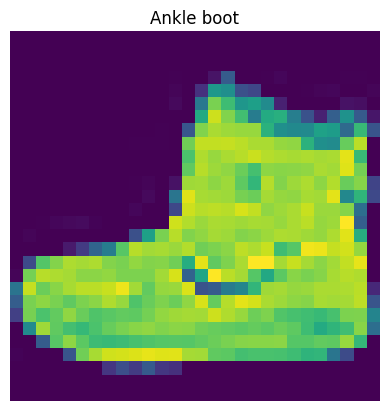

In [ ]:
plt.imshow(image.squeeze())
plt.title(class_names[label])
plt.axis("off")

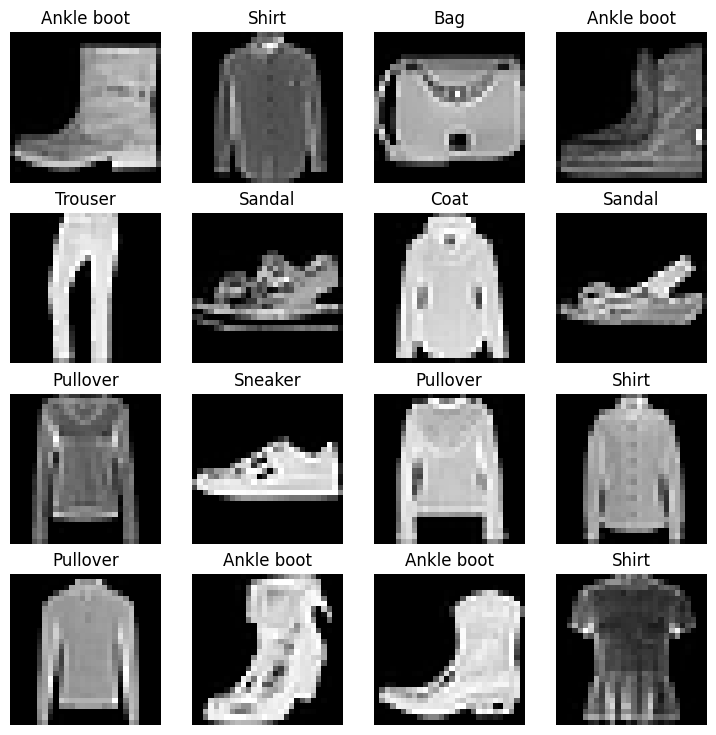

In [ ]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols = 4,4

for i in range(1,rows*cols+1):
  random_idx = torch.randint(0,len(train_data), size = [1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(img.squeeze(),cmap = "gray")
  plt.title(class_names[label])
  plt.axis("off")

## Data loader

Converting Pytorch datasets into python iterables by splitting the dataset into smaller batches so that it is processed easily by the models computations hardware and provides neural network to update over each epochs.

In [ ]:
from torch.utils.data import DataLoader


BATCH_SIZE =32

train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              shuffle= True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size =   BATCH_SIZE,
                             shuffle = False)

In [ ]:

print(f" Dataloaders ={train_dataloader,test_dataloader}")
print(f" Length of train dataloader = {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f" Length of test dataloader = {len(test_dataloader)} batches of {BATCH_SIZE} ")

 Dataloaders =(<torch.utils.data.dataloader.DataLoader object at 0x7a08d82b36e0>, <torch.utils.data.dataloader.DataLoader object at 0x7a08d818f140>)
 Length of train dataloader = 1875 batches of 32
 Length of test dataloader = 313 batches of 32 


train features size = torch.Size([32, 1, 28, 28]), Train labels size = torch.Size([32])
image size =torch.Size([1, 28, 28])
Label: 6, label size = torch.Size([])


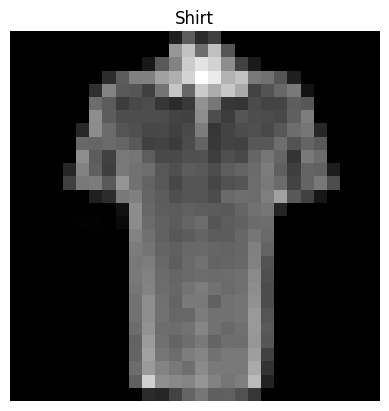

In [ ]:
train_features_batch,train_labels_batch = next(iter(train_dataloader))
print(f"train features size = {train_features_batch.shape}, Train labels size = {train_labels_batch.shape}")#batch size , color samples, height , width
torch.manual_seed(42)
random_idx = torch.randint(0,len(train_features_batch), size = [1]).item()
img,label = train_features_batch[random_idx],train_labels_batch[random_idx]
plt.imshow(img.squeeze(),cmap="gray")
plt.title(class_names[label])
plt.axis(False)
print(f"image size ={img.shape}")
print(f"Label: {label}, label size = {label.shape}")


# Baseline Model

In [ ]:
flatten_model = nn.Flatten()

x= train_features_batch[0]

output = flatten_model(x)

print(f"shape before flattening:{x.shape}")
print(f"shape after the flattening:{output.shape}")

shape before flattening:torch.Size([1, 28, 28])
shape after the flattening:torch.Size([1, 784])


In [ ]:
output.squeeze()

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0039, 0.0039, 0.0000, 0.0000, 0.0078, 0.0078,
        0.0000, 0.0000, 0.0039, 0.0078, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.2863, 0.0000, 0.0000, 0.0078, 

Flattening converts whole 28*28 dim picture into a single pixel

In [ ]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
  def __init__(self, input_shape: int, hidden_units:int, output_shape:int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape)
    )
  def forward(self,x):
    return self.layer_stack(x)



In [ ]:
torch.manual_seed(42)

model_0 = FashionMNISTModelV0(input_shape = 784, #28*28
                      hidden_units = 10, # units for hidden layer
                      output_shape = len(class_names) # length of every class layer
).to("cpu")
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
dummy_x = torch.rand(1,1,28,28)
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [ ]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

## loss function and optimizer finally evaluation metrics


* Loss Function: since the model has different classes more than 2 we have a multi-class classification model so we use Cross Entropy Loss func.

* Optimizer: stochastic Gradient Descent SGD

* Evalluation Metric: class we are working on is classification problem so we use accuracy

In [ ]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with  open("helper_functions.py","wb") as f:
    f.write(request.content)

helper_functions.py already exists


In [ ]:
# Import accuracy metric


from helper_functions import accuracy_fn

#Setup loss function
loss_fn = nn.CrossEntropyLoss()

#Setup optimizer
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.1)


## Function to track the model

ML is experimental:

* Model's Performance test
* Precision of speed of model

In [ ]:
from timeit import default_timer as timer
def print_train_time(start: float,
                     end: float,
                     device:torch.device =None):
  total_time = end-start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time


In [ ]:
start_time = timer()
print("dhsdfg")
print(x.flatten())
end_time = timer()

print_train_time(start = start_time, end=end_time, device="cpu")

dhsdfg
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0039, 0.0039, 0.0000, 0.0000, 0.0078, 0.0078,
        0.0000, 0.0000, 0.0039, 0.0078, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.2863, 0.0000, 0.0000, 0

0.00574938300019312

## Creating a training and testing loop over batches  of data

In [ ]:
# import tqdm for progress bar
from tqdm.auto import tqdm

torch.manual_seed(42)
train_time_start_on_cpu = timer()

epochs = 3

# Create train and test loop

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n ----------")
  train_loss = 0

  for batch, (X,y) in enumerate(train_dataloader):
    model_0.train()
    # Forward Pass
    y_pred = model_0(X)

    # Calculate loss per batch
    loss = loss_fn(y_pred, y)
    train_loss += loss

    # Optimizer zero grad
    optimizer.zero_grad()

    # Loss backward
    loss.backward()

    # Optimizer step
    optimizer.step()

    # Visualization
    if batch % 400 ==0:
      print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples ")

  train_loss /= len(train_dataloader)
  print(f"Train loss: {train_loss:.4f}")

  # testing loop

  test_loss, test_acc = 0,0

  model_0.eval()

  with torch.inference_mode():
    for X_test,y_test in test_dataloader:
      test_pred = model_0(X_test)
      test_loss += loss_fn(test_pred, y_test)
      test_acc += accuracy_fn(y_true = y_test,
                              y_pred = test_pred.argmax(dim=1))
    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)
  print(f"Test loss: {test_loss:.4f}")
  print(f"Test acc: {test_acc:.4f}")
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                            end=train_time_end_on_cpu,
                                            device=str(next(model_0.parameters()).device))



  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
 ----------
Looked at 0/60000 samples 
Looked at 12800/60000 samples 
Looked at 25600/60000 samples 
Looked at 38400/60000 samples 
Looked at 51200/60000 samples 
Train loss: 0.5904
Test loss: 0.5095
Test acc: 82.0387
Epoch: 1
 ----------
Looked at 0/60000 samples 
Looked at 12800/60000 samples 
Looked at 25600/60000 samples 
Looked at 38400/60000 samples 
Looked at 51200/60000 samples 
Train loss: 0.4763
Test loss: 0.4799
Test acc: 83.1969
Epoch: 2
 ----------
Looked at 0/60000 samples 
Looked at 12800/60000 samples 
Looked at 25600/60000 samples 
Looked at 38400/60000 samples 
Looked at 51200/60000 samples 
Train loss: 0.4550
Test loss: 0.4766
Test acc: 83.4265
Train time on cpu: 33.812 seconds


## Make predictions and get model0 result

In [ ]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
                loss_f: torch.nn.Module,
               accuracy_fn):
  """ Function for returning dictionary containing results of predictions made by model over dataloader. """
  loss, acc = 0,0
  model.eval()
  with torch.inference_mode():
    for X,y in tqdm(data_loader):
      y_pred = model(X)
      loss += loss_f(y_pred,y)
      acc += accuracy_fn(y_true = y,
                         y_pred = y_pred.argmax(dim=1)
                         # logits with max index value is put in softmax func
                         )
    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__,#only applicable if model contains class names
          "model_loss": loss.item(),
          "model_acc": acc}

model_0_results = eval_model(model=model_0,
                            data_loader=test_dataloader,
                            loss_f=loss_fn,
                            accuracy_fn=accuracy_fn)
model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

## Setup Device agnostic code


In [ ]:
!nvidia-smi
device = "cuda" if torch.cuda.is_available() else "cpu"
device

Fri Jun 26 18:29:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

'cuda'

# Model 1: Imporvise Model0 with non-linearity

In [ ]:
# Create non-linear and linear layers

class FashionMNISTModelV1(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units:int,
               output_shape:int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape),
        nn.ReLU()
    )
  def forward(self,x):
    return self.layer_stack(x)

In [ ]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784,
                              hidden_units=10,
                              output_shape=len(class_names)).to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

## Create loss, optimizer and evaluation metrics

In [ ]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer =torch.optim.SGD(params=model_1.parameters(),
                             lr=0.1)


## Functionizing training and evaluation /testing loop

Lets create function for

training loop = train_step()
testing loop = test_step()


In [ ]:
def train_step( model: torch.nn.Module,
                data_loader: torch.utils.data.DataLoader,
                loss_fn: torch.nn.Module,
                optimizer: torch.optim.Optimizer,
                accuracy_fn,
                device: torch.device = device
                ):

  """ Perform training with model trying to learn over Dataloader"""
  train_loss,train_acc = 0, 0

  model.train()
  for batch, (X,y) in enumerate(train_dataloader):
    X,y = X.to(device), y.to(device)
    # Forward Pass
    y_pred = model(X)

    # Calculate loss per batch
    loss = loss_fn(y_pred, y)
    train_loss += loss
    train_acc += accuracy_fn(y_true = y,
                             y_pred = y_pred.argmax(dim = 1))

    # Optimizer zero grad
    optimizer.zero_grad()

    # Loss backward
    loss.backward()

    # Optimizer step
    optimizer.step()

    # Visualization
    if batch % 400 ==0:
      print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples ")

  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)
  print(f"Train loss: {train_loss:.5f}, | Train accuracy : {train_acc:.2f}")


In [ ]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
  """ Perform testing of model that's trying to learn over Dataloader"""

  test_loss, test_acc = 0,0

  model.eval()

  with torch.inference_mode():
    for X,y in data_loader:
      X,y = X.to(device),y.to(device)
      test_pred = model(X)
      test_loss += loss_fn(test_pred, y)
      test_acc += accuracy_fn(y_true = y,
                              y_pred = test_pred.argmax(dim=1))
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

    print(f"Teest loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}% \n")

In [ ]:
torch.manual_seed(42)
from timeit import default_timer as timer

train_time_start_on_gpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n ----------")
  train_step(model = model_1,
             data_loader = train_dataloader,
             loss_fn = loss_fn,
             optimizer = optimizer,
             accuracy_fn = accuracy_fn,
             device = device)
  test_step(model = model_1,
            data_loader = test_dataloader,
            loss_fn = loss_fn,
            accuracy_fn = accuracy_fn,
            device= device)


train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
 ----------
Looked at 0/60000 samples 
Looked at 12800/60000 samples 
Looked at 25600/60000 samples 
Looked at 38400/60000 samples 
Looked at 51200/60000 samples 
Train loss: 1.09199, | Train accuracy : 61.34
Teest loss: 0.95636 | Test accuracy: 65.00% 

Epoch: 1
 ----------
Looked at 0/60000 samples 
Looked at 12800/60000 samples 
Looked at 25600/60000 samples 
Looked at 38400/60000 samples 
Looked at 51200/60000 samples 
Train loss: 0.78101, | Train accuracy : 71.93
Teest loss: 0.72227 | Test accuracy: 73.91% 

Epoch: 2
 ----------
Looked at 0/60000 samples 
Looked at 12800/60000 samples 
Looked at 25600/60000 samples 
Looked at 38400/60000 samples 
Looked at 51200/60000 samples 
Train loss: 0.67027, | Train accuracy : 75.94
Teest loss: 0.68500 | Test accuracy: 75.02% 

Train time on cuda: 31.695 seconds


In [ ]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

In [ ]:
total_train_time_model_0

33.8115264569999

In [ ]:
!nvidia-smi

Fri Jun 26 18:54:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P0             30W /   70W |     161MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
                loss_f: torch.nn.Module,
               accuracy_fn,
               device = device):
  """ Function for returning dictionary containing results of predictions made by model over dataloader. """
  loss, acc = 0,0
  model.eval()
  with torch.inference_mode():
    for X,y in tqdm(data_loader):
      # Make our data device agnostic
      X,y = X.to(device),y.to(device)
      y_pred = model(X)
      loss += loss_f(y_pred,y)
      acc += accuracy_fn(y_true = y,
                         y_pred = y_pred.argmax(dim=1)
                         # logits with max index value is put in softmax func
                         )
    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__,#only applicable if model contains class names
          "model_loss": loss.item(),
          "model_acc": acc}


In [ ]:
model_1_results = eval_model(model=model_1,
                            data_loader=test_dataloader,
                            loss_f=loss_fn,
                            accuracy_fn=accuracy_fn,
                            device=device)
model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6850008964538574,
 'model_acc': 75.01996805111821}

In [ ]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

Model 1 is faster than model 0 but model 0 is more accurate than model 1

# Model 2: Building a Convutional Neural Network (CNN) aka ConvNets

Known for their capabilities to find patterns in visual data